# Column Standardization To-Do List

- [ ] Verify remapping of `Tissue` and `Cell Type`
- [ ] Create Standardized naming convention for `Classification`
- [ ] Tissue source Mapping using Uberon
- [ ] Cell type mapping using Cell Ontology

##### Load libraries

In [20]:
import pandas as pd
import os
import re

In [ ]:
# initialize dataframes to clean
tb_cleaned = pd.read_csv('../labeling/TB/TB_manCleaned.tsv', sep = '\t')

# Help Functions

##### Column-specific Helper Functions

In [3]:
def print_unique_counts_and_values(df, columns):
    """
    Prints the number of unique values and the unique values themselves for each column in columns.
    """
    print("Unique counts for specified columns:")
    print(df[columns].nunique())
    print("\n")
    for col in columns:
        print(f"Unique values in {col}:")
        print(df[col].unique())
        print()

def remap_and_insert_clean_column(df: pd.DataFrame, column: str, remap_dict: dict, suffix: str):
    """
    Remap values in a column using remap_dict, add a new column with remapped values,
    and reorder columns so the new column is next to the original.
    
    Parameters:
        df (pd.DataFrame): Input dataframe (already cleaned).
        column (str): Column to remap.
        remap_dict (dict): Dictionary for remapping.
        suffix (str): Suffix for new column name (default: '_CLEAN').
    
    Returns:
        pd.DataFrame: DataFrame with new column and reordered columns.
    """
    print(f"Original values in {column}:")
    print(df[column].unique())
    print(df[column].nunique())
    clean_col = f"{column}_{suffix}"
    df[clean_col] = df[column].map(remap_dict).fillna(df[column])
    # Move the new column to the right of the original
    cols = list(df.columns)
    cols.remove(clean_col)
    insert_at = cols.index(column) + 1
    cols = cols[:insert_at] + [clean_col] + cols[insert_at:]
    df = df[cols]
    print(f"Remapped values in {clean_col}:")
    print(df[clean_col].unique())
    print(df[clean_col].nunique())
    return df

def does_gse_match(doc, man) -> bool:
    """
    purpose: checks if the GSE_IDs in doc with status PRESENT match the GSE_IDs in man
    """
    doc_gse_ids = doc.loc[doc["status"] == "PRESENT", "GSE_ID"]
    man_gse_ids = man["GSE_ID"]
    # convert to sets for comparison
    doc_set = set(doc_gse_ids)
    man_set = set(man_gse_ids)
    return doc_set == man_set


# Check Labeling : TB

In [17]:
TBman = pd.read_csv('../labeling/TB/TB_man.tsv', sep='\t') 
print_unique_counts_and_values(TBman, ['CLASSIFICATION', 'SAMPLE_TYPE', 'CELL_SOURCE', 'TISSUE_SOURCE', 'CONTEXT'])

Unique counts for specified columns:
CLASSIFICATION     2
SAMPLE_TYPE        2
CELL_SOURCE       25
TISSUE_SOURCE     10
CONTEXT            0
dtype: int64


Unique values in CLASSIFICATION:
['Healthy Control without treatment' 'Disease without treatment']

Unique values in SAMPLE_TYPE:
['blood_sample' 'primary_sample']

Unique values in CELL_SOURCE:
['whole blood' 'PBMC' 'PBMCs' 'PBMCs (Peripheral Blood Mononuclear Cells)'
 'PBMCs (peripheral blood mononuclear cells)' 'THP-1' 'lung' 'lung tissue'
 'Human stem cell-derived macrophage' 'EB7' 'blood mononuclear cells'
 'CD14+ monocytes' 'PBMC (peripheral blood mononuclear cells)'
 'PBMC (Peripheral Blood Mononuclear Cells)' 'Whole Blood'
 'Bronchoalveolar lavage fluid' 'HepG2' 'Dendritic cells (DCs)'
 'Monocyte-derived dendritic (DCs)' 'blood' 'Blood' 'macrophages'
 'bronchoalveolar lavage' 'marcophages' 'macrophage']

Unique values in TISSUE_SOURCE:
['WHOLE_BLOOD' 'PBMC' 'CELL_LINE_THP1' 'LUNG_TISSUE_GENERAL'
 'MACROPHAGES_GENERAL' 'BALF

In [68]:
TB_CELL_SOURCE_REMAP = {
    'whole blood' : 'Blood Cells',
	'Whole Blood' : 'Blood Cells',
	'blood' : 'Blood Cells',
	'Blood' : 'Blood Cells',
	
	'PBMC'  : 'PBMCs',
	'PBMCs' : 'PBMCs',
	'PBMCs (Peripheral Blood Mononuclear Cells)' : 'PBMCs',
    'PBMCs (peripheral blood mononuclear cells)' : 'PBMCs',
	'PBMC (peripheral blood mononuclear cells)' : 'PBMCs',
	'PBMC (Peripheral Blood Mononuclear Cells)' : 'PBMCs',
	
	'blood mononuclear cells' : 'Monocytes',
	
	
	'THP-1' : 'THP1',
	
	'lung' : 'Lung',
	'lung tissue' : 'Lung',
	
	
	'EB7' : 'EB7',
	'CD14+ monocytes' : 'CD14+ Monocytes',
	'HepG2' : 'HepG2',
	
	'Dendritic cells (DCs)' : 'Dendritic Cells',
	'Monocyte-derived dendritic (DCs)' : 'monocyte-derived dendritic cells',
	
	'Human stem cell-derived macrophage' : 'macrophages',
	'macrophages' : 'macrophages',
	'macrophages' : 'macrophages',
	'macrophage' : 'macrophages',

	'bronchoalveolar_lavage' : 'BALF',
	'Bronchoalveolar lavage fluid' : 'BALF',
}

TB_TISSUE_SOURCE_REMAP = {
'WHOLE_BLOOD' : 'Blood',
'BLOOD_GENERAL' : 'Blood',
'PBMC' : 'Blood',
'CELL_LINE_THP1' : 'THP1',
'LUNG_TISSUE_GENERAL' : 'Lung',
'MACROPHAGES_GENERAL' : 'Macrophages',
'CELL_LINE_HEPG2' : 'HepG2',
'MONOCYTES_GENERAL' : 'Monocytes',
'BALF_BRONCHOALVEOLAR_LAVAGE_FLUID' : 'BALF',
'BAL_BRONCHOALVEOLAR_LAVAGE_GENERAL' : 'BALF',
}

In [69]:
remap_and_insert_clean_column(TBman, 'CELL_SOURCE', TB_CELL_SOURCE_REMAP, 'CLEAN')

Original values in CELL_SOURCE:
['whole blood' 'PBMC' 'PBMCs' 'PBMCs (Peripheral Blood Mononuclear Cells)'
 'PBMCs (peripheral blood mononuclear cells)' 'THP-1' 'lung' 'lung tissue'
 'Human stem cell-derived macrophage' 'EB7' 'blood mononuclear cells'
 'CD14+ monocytes' 'PBMC (peripheral blood mononuclear cells)'
 'PBMC (Peripheral Blood Mononuclear Cells)' 'Whole Blood'
 'Bronchoalveolar lavage fluid' 'HepG2' 'Dendritic cells (DCs)'
 'Monocyte-derived dendritic (DCs)' 'blood' 'Blood' 'macrophages'
 'bronchoalveolar lavage' 'marcophages' 'macrophage']
25
Remapped values in CELL_SOURCE_CLEAN:
['Blood Cells' 'PBMCs' 'THP1' 'Lung' 'macrophages' 'EB7' 'Monocytes'
 'CD14+ Monocytes' 'BALF' 'HepG2' 'Dendritic Cells'
 'monocyte-derived dendritic cells' 'bronchoalveolar lavage' 'marcophages']
14


,GSE_ID,GSM_ID,CLASSIFICATION,SAMPLE_TYPE,CELL_SOURCE,CELL_SOURCE_CLEAN,TISSUE_SOURCE,TISSUE_SOURCE_CLEAN,CONTEXT
0,GSE84076,GSM2226808,Healthy Control without treatment,blood_sample,whole blood,Blood Cells,WHOLE_BLOOD,Blood,NaN
1,GSE84076,GSM2226809,Disease without treatment,blood_sample,whole blood,Blood Cells,WHOLE_BLOOD,Blood,NaN
2,GSE84076,GSM2226817,Disease without treatment,blood_sample,whole blood,Blood Cells,WHOLE_BLOOD,Blood,NaN
3,GSE84076,GSM2226825,Healthy Control without treatment,blood_sample,whole blood,Blood Cells,WHOLE_BLOOD,Blood,NaN
4,GSE84076,GSM2226829,Healthy Control without treatment,blood_sample,whole blood,Blood Cells,WHOLE_BLOOD,Blood,NaN
...,...,...,...,...,...,...,...,...,...
555,GSE236156,GSM7519008,Disease without treatment,primary_sample,bronchoalveolar lavage,bronchoalveolar lavage,BAL_BRONCHOALVEOLAR_LAVAGE_GENERAL,BALF,NaN
556,GSE236156,GSM7519009,Healthy Control without treatment,primary_sample,bronchoalveolar lavage,bronchoalveolar lavage,BAL_BRONCHOALVEOLAR_LAVAGE_GENERAL,BALF,NaN
557,GSE236156,GSM7519010,Healthy Control without treatment,primary_sample,bronchoalveolar lavage,bronchoalveolar lavage,BAL_BRONCHOALVEOLAR_LAVAGE_GENERAL,BALF,NaN
558,GSE236156,GSM7519011,Disease without treatment,primary_sample,bronchoalveolar lavage,bronchoalveolar lavage,BAL_BRONCHOALVEOLAR_LAVAGE_GENERAL,BALF,NaN


In [20]:
remap_and_insert_clean_column(TBman, 'TISSUE_SOURCE', TB_TISSUE_SOURCE_REMAP, 'CLEAN')

Original values in TISSUE_SOURCE:
['WHOLE_BLOOD' 'PBMC' 'CELL_LINE_THP1' 'LUNG_TISSUE_GENERAL'
 'MACROPHAGES_GENERAL' 'BALF_BRONCHOALVEOLAR_LAVAGE_FLUID'
 'CELL_LINE_HEPG2' 'MONOCYTES_GENERAL' 'BLOOD_GENERAL'
 'BAL_BRONCHOALVEOLAR_LAVAGE_GENERAL']
10
Remapped values in TISSUE_SOURCE_CLEAN:
['Blood' 'THP1' 'Lung' 'Macrophages' 'BALF' 'HepG2' 'Monocytes']
7


,GSE_ID,GSM_ID,CLASSIFICATION,SAMPLE_TYPE,CELL_SOURCE,TISSUE_SOURCE,TISSUE_SOURCE_CLEAN,CONTEXT,CELL_SOURCE_CLEAN
0,GSE84076,GSM2226808,Healthy Control without treatment,blood_sample,whole blood,WHOLE_BLOOD,Blood,NaN,Whole Blood
1,GSE84076,GSM2226809,Disease without treatment,blood_sample,whole blood,WHOLE_BLOOD,Blood,NaN,Whole Blood
2,GSE84076,GSM2226817,Disease without treatment,blood_sample,whole blood,WHOLE_BLOOD,Blood,NaN,Whole Blood
3,GSE84076,GSM2226825,Healthy Control without treatment,blood_sample,whole blood,WHOLE_BLOOD,Blood,NaN,Whole Blood
4,GSE84076,GSM2226829,Healthy Control without treatment,blood_sample,whole blood,WHOLE_BLOOD,Blood,NaN,Whole Blood
...,...,...,...,...,...,...,...,...,...
555,GSE236156,GSM7519008,Disease without treatment,primary_sample,bronchoalveolar lavage,BAL_BRONCHOALVEOLAR_LAVAGE_GENERAL,BALF,NaN,bronchoalveolar lavage
556,GSE236156,GSM7519009,Healthy Control without treatment,primary_sample,bronchoalveolar lavage,BAL_BRONCHOALVEOLAR_LAVAGE_GENERAL,BALF,NaN,bronchoalveolar lavage
557,GSE236156,GSM7519010,Healthy Control without treatment,primary_sample,bronchoalveolar lavage,BAL_BRONCHOALVEOLAR_LAVAGE_GENERAL,BALF,NaN,bronchoalveolar lavage
558,GSE236156,GSM7519011,Disease without treatment,primary_sample,bronchoalveolar lavage,BAL_BRONCHOALVEOLAR_LAVAGE_GENERAL,BALF,NaN,bronchoalveolar lavage


In [21]:
TBman = TBman[['GSE_ID', 'GSM_ID', 'CLASSIFICATION',
       'SAMPLE_TYPE', 'CELL_SOURCE', 'CELL_SOURCE_CLEAN', 'TISSUE_SOURCE',
       'TISSUE_SOURCE_CLEAN', 'CONTEXT']]

TBman.head()

,GSE_ID,GSM_ID,CLASSIFICATION,SAMPLE_TYPE,CELL_SOURCE,CELL_SOURCE_CLEAN,TISSUE_SOURCE,TISSUE_SOURCE_CLEAN,CONTEXT
0,GSE84076,GSM2226808,Healthy Control without treatment,blood_sample,whole blood,Whole Blood,WHOLE_BLOOD,Blood,NaN
1,GSE84076,GSM2226809,Disease without treatment,blood_sample,whole blood,Whole Blood,WHOLE_BLOOD,Blood,NaN
2,GSE84076,GSM2226817,Disease without treatment,blood_sample,whole blood,Whole Blood,WHOLE_BLOOD,Blood,NaN
3,GSE84076,GSM2226825,Healthy Control without treatment,blood_sample,whole blood,Whole Blood,WHOLE_BLOOD,Blood,NaN
4,GSE84076,GSM2226829,Healthy Control without treatment,blood_sample,whole blood,Whole Blood,WHOLE_BLOOD,Blood,NaN


## Visual sample distribution across diseases

In [4]:
import matplotlib.pyplot as plt

def plot_gsm_counts_by_disease_stacked(disease_dfs):
    """
    Plots a stacked bar chart of GSM counts by classification for each disease.
    X-axis: diseases, stacked by classification.
    """
    diseases = list(disease_dfs.keys())
    # Find all possible classification categories
    all_classes = set()
    for df in disease_dfs.values():
        class_col = 'CLASSIFICATION_STANDARDIZED' if 'CLASSIFICATION_STANDARDIZED' in df.columns else 'CLASSIFICATION'
        all_classes.update(df[class_col].unique())
    all_classes = sorted(all_classes)

    # Prepare data
    counts = {cls: [] for cls in all_classes}
    for disease in diseases:
        df = disease_dfs[disease]
        class_col = 'CLASSIFICATION_STANDARDIZED' if 'CLASSIFICATION_STANDARDIZED' in df.columns else 'CLASSIFICATION'
        group = df.groupby(class_col)['GSM_ID'].nunique()
        for cls in all_classes:
            counts[cls].append(group.get(cls, 0))

    # Plot stacked bars
    x = range(len(diseases))
    fig, ax = plt.subplots(figsize=(8, 6))
    bottom = [0] * len(diseases)
    for cls in all_classes:
        ax.bar(
            x,
            counts[cls],
            bottom=bottom,
            label=cls
        )
        bottom = [b + c for b, c in zip(bottom, counts[cls])]
    ax.set_xticks(x)
    ax.set_xticklabels(diseases)
    ax.set_ylabel('Number of Samples')
    ax.set_title('sample counts by disease (stacked)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('images/GeneralDiseasePlots/SampleDistribution.png', dpi=300)
    plt.show()

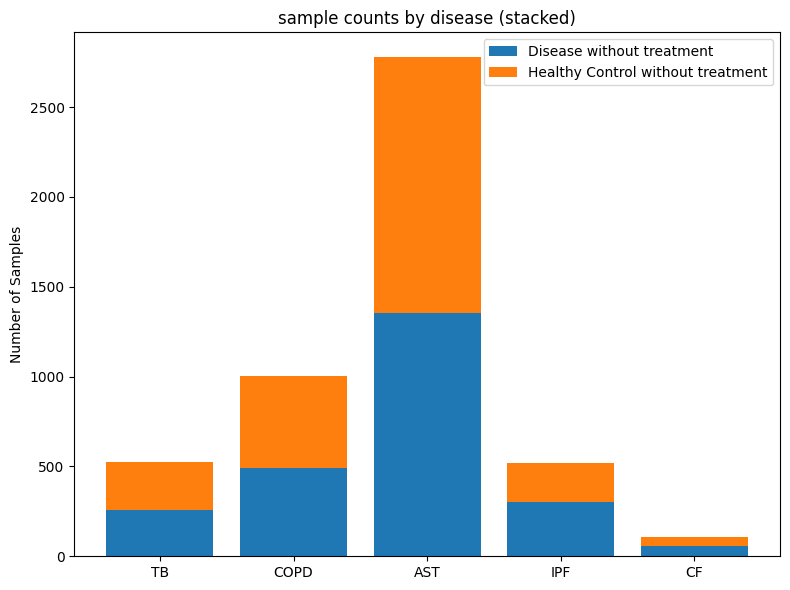

In [5]:
disease_dfs = {
	"TB": TBman,
	"COPD": COPDman,
	"AST": ASTman,
	"IPF": IPFman,
	"CF": CFman,
}

plot_gsm_counts_by_disease_stacked(disease_dfs)

# Checking for Single Cell RNA-seq data

In [ ]:
TB_metadata_path = '../data/metadata/TB'

In [115]:
def keyword_search(path, keyword):
	"""
	Searches all .tsv files in a directory for columns where any cell contains the keyword(s).
	Returns a list of (filename, found_columns) for files with matches, or prints a message if no hits.
	"""
	results = []
	for fname in os.listdir(path):
		full_path = os.path.join(path, fname)
		if os.path.isfile(full_path) and fname.endswith('.tsv'):
			df = pd.read_csv(full_path, sep='\t')
			# keyword can be a string or list of strings
			if isinstance(keyword, str):
				keywords = [keyword]
			else:
				keywords = keyword
			# Find columns where any cell contains any of the keywords (case-insensitive)
			mask = df.apply(lambda col: col.astype(str).str.contains('|'.join(keywords), case=False, na=False))
			columns_with_keyword = mask.any(axis=0)
			found_columns = columns_with_keyword[columns_with_keyword].index.tolist()
			if found_columns:
				results.append((fname, found_columns))
	if not results:
		print(f"No columns containing keyword(s) found in any .tsv file in {path}")
		return None
	return results

In [117]:
keyword_search(TB_metadata_path, ["single-cell", "single cell", "scRNA", "scRNA-seq", "scRNAseq", "scRNA seq"])

No columns containing keyword(s) found in any .tsv file in ../data/metadata/TB


# CONCAT GEO metadata with manual labeling

In [ ]:
def extract_cols_with_counts(path):
	"""
	Extracts all unique column names from files in a directory and counts in how many files each column appears.
	Returns a dictionary {column_name: count}.
	"""
	col_counts = {}
	for filename in os.listdir(path):
		file_path = os.path.join(path, filename)
		if os.path.isfile(file_path):
			df = pd.read_csv(file_path, sep='\t')
			for col in set(df.columns):
				col_counts[col] = col_counts.get(col, 0) + 1
	return col_counts

In [ ]:
# print the number of files in the path
path = '../data/metadata/TB-JUN'
print("Number of files in the path:", len(os.listdir(path)))

# Usage
col_counts = extract_cols_with_counts(path)
# To get sorted list of columns and their counts:
sorted_col_counts = sorted(col_counts.items(), key=lambda x: x[1], reverse=True)
sorted_col_counts

Number of files in the path: 49


[('contact_name', 49),
 ('contact_institute', 49),
 ('characteristics_ch1', 49),
 ('relation', 49),
 ('contact_country', 49),
 ('submission_date', 49),
 ('channel_count', 49),
 ('series_id', 49),
 ('last_update_date', 49),
 ('library_selection', 49),
 ('organism_ch1', 49),
 ('platform_id', 49),
 ('data_processing.1', 49),
 ('status', 49),
 ('relation.1', 49),
 ('supplementary_file_1', 49),
 ('source_name_ch1', 49),
 ('data_processing.2', 49),
 ('contact_city', 49),
 ('geo_accession', 49),
 ('library_strategy', 49),
 ('contact_zip/postal_code', 49),
 ('instrument_model', 49),
 ('library_source', 49),
 ('molecule_ch1', 49),
 ('type', 49),
 ('data_processing', 49),
 ('contact_address', 49),
 ('taxid_ch1', 49),
 ('data_row_count', 49),
 ('title', 49),
 ('extract_protocol_ch1', 49),
 ('characteristics_ch1.1', 48),
 ('extract_protocol_ch1.1', 48),
 ('data_processing.3', 43),
 ('contact_email', 42),
 ('data_processing.4', 39),
 ('treatment_protocol_ch1', 37),
 ('characteristics_ch1.2', 37),
 

In [ ]:
# Only process files whose GSE ID is in acceptablestudies
filtered_files = [
	f for f in os.listdir(path)
	if os.path.isfile(os.path.join(path, f)) and
	   any(gse in f for gse in acceptablestudies)
]

print("Number of acceptable files in the path:", len(filtered_files))

col_counts = {}
for filename in filtered_files:
	file_path = os.path.join(path, filename)
	df = pd.read_csv(file_path, sep='\t')
	for col in set(df.columns):
		col_counts[col] = col_counts.get(col, 0) + 1

sorted_col_counts = sorted(col_counts.items(), key=lambda x: x[1], reverse=True)
sorted_col_counts

Number of acceptable files in the path: 24


[('contact_name', 24),
 ('contact_institute', 24),
 ('characteristics_ch1', 24),
 ('relation', 24),
 ('contact_country', 24),
 ('submission_date', 24),
 ('channel_count', 24),
 ('series_id', 24),
 ('last_update_date', 24),
 ('library_selection', 24),
 ('organism_ch1', 24),
 ('platform_id', 24),
 ('data_processing.1', 24),
 ('status', 24),
 ('relation.1', 24),
 ('supplementary_file_1', 24),
 ('source_name_ch1', 24),
 ('data_processing.2', 24),
 ('contact_city', 24),
 ('geo_accession', 24),
 ('library_strategy', 24),
 ('contact_zip/postal_code', 24),
 ('instrument_model', 24),
 ('extract_protocol_ch1.1', 24),
 ('library_source', 24),
 ('molecule_ch1', 24),
 ('type', 24),
 ('data_processing', 24),
 ('contact_address', 24),
 ('taxid_ch1', 24),
 ('data_row_count', 24),
 ('title', 24),
 ('extract_protocol_ch1', 24),
 ('characteristics_ch1.1', 23),
 ('contact_email', 20),
 ('treatment_protocol_ch1', 19),
 ('data_processing.3', 19),
 ('growth_protocol_ch1', 18),
 ('characteristics_ch1.2', 18),

In [ ]:
cols_of_interest = [
	'series_id',
	'geo_accession',
	'title',
	'source_name_ch1',
	'organism_ch1',
	'characteristics_ch1',
	'characteristics_ch1.1',
	'characteristics_ch1.2',
	'molecule_ch1',
	'platform_id',
	'library_source',
	'library_strategy',
	'cell type:ch1',
	'tissue:ch1',
	'time:ch1',
	'time point:ch1',
]



In [ ]:
def create_mega_df_from_dir(input_dir, cleandf, cols_of_interest, use_NA_string=False):
    """
    Iterates over all files in input_dir, extracts cols_of_interest, 
    keeps only rows with series_id and geo_accession in cleandf,
    and returns the combined DataFrame.
    Missing columns are filled with 'NA' if use_NA_string is True, otherwise left as NaN.
    """
    mega_df = []
    valid_gse = set(cleandf['GSE_ID'])
    valid_gsm = set(cleandf['GSM_ID'])

    for fname in os.listdir(input_dir):
        if fname.endswith('.tsv'):
            fpath = os.path.join(input_dir, fname)
            df = pd.read_csv(fpath, sep='\t')
            # Ensure all columns of interest are present, fill missing with NaN
            df = df.reindex(columns=cols_of_interest)
            # Filter rows
            if 'series_id' in df.columns and 'geo_accession' in df.columns:
                df = df[df['series_id'].isin(valid_gse) & df['geo_accession'].isin(valid_gsm)]
                mega_df.append(df)
    if mega_df:
        mega_df = pd.concat(mega_df, ignore_index=True)
        if use_NA_string:
            mega_df = mega_df.fillna('NA')
        return mega_df
    else:
        print("No data found matching criteria.")
        return pd.DataFrame(columns=cols_of_interest)

In [ ]:
TBmeta = create_mega_df_from_dir(path, cleaned_df_tb, cols_of_interest)

In [ ]:
TBmeta.shape 

(560, 16)

In [ ]:
cleaned_df_tb.shape

(560, 8)

##### merge metadata with signature data

In [ ]:
columns_list = [
	'organism_ch1',
	'GSE_ID', 
	'GSM_ID',
	'series_id',
	'geo_accession',
	'classification',
	'title',
	'sample_type',
	'tissue_cell',
	'imputed_tissue',
	'source_name_ch1',
	'characteristics_ch1',
	'characteristics_ch1.1',
	'characteristics_ch1.2',
	'molecule_ch1',
	'platform_id',
	'library_source',
	'library_strategy',
	'cell type:ch1',
	'tissue:ch1',
	'time:ch1', 
	'time point:ch1'
	'reason',
	'treatment'
]


In [ ]:
def merge_signature_and_metadata(signature_df, metadata_df):
	"""
	Merge signature and metadata dataframes on series_id/GSE_ID and geo_accession/GSM_ID.
	Ensures the resulting columns are ordered according to columns_list.
	"""
	merged = pd.merge(
		signature_df,
		metadata_df,
		left_on=['GSE_ID', 'GSM_ID'],
		right_on=['series_id', 'geo_accession'],
		how='inner'
	)
	# Only keep columns present in columns_list and order them
	merged = merged[[col for col in columns_list if col in merged.columns]]
	return merged

In [ ]:
merge_signature_and_metadata = merge_signature_and_metadata(cleaned_df_tb, TBmeta)

In [ ]:
# to csv
#merge_signature_and_metadata.to_csv('TB_meta_merged2.tsv', sep='\t', index=False)

In [ ]:
tbfinal = pd.read_csv('/Users/lingthang/JRaviLab/RNAseq_DEanalysis-Ling/Notebooks/TB_FINAL.tsv', sep='\t', index_col= False)
tbfinal2 = pd.read_csv('/Users/lingthang/JRaviLab/RNAseq_DEanalysis-Ling/data/FinalSignatures/TB_FINAL.tsv', sep='\t', index_col= False)


In [ ]:
tbfinal2.shape

(560, 21)

In [ ]:
print(tbfinal.columns)
print(tbfinal2.columns)

Index(['index', 'organism_ch1', 'series_id', 'geo_accession', 'CLASSIFICATION',
       'title', 'SAMPLE_TYPE', 'CELL', 'TISSUE', 'source_name_ch1',
       'characteristics_ch1', 'characteristics_ch1.1', 'characteristics_ch1.2',
       'molecule_ch1', 'platform_id', 'library_source', 'library_strategy',
       'cell type:ch1', 'tissue:ch1', 'time:ch1'],
      dtype='object')
Index(['organism_ch1', 'GSE_ID', 'GSM_ID', 'series_id', 'geo_accession',
       'CLASSIFICATION', 'title', 'SAMPLE_TYPE', 'CELL', 'TISSUE',
       'source_name_ch1', 'characteristics_ch1', 'characteristics_ch1.1',
       'characteristics_ch1.2', 'molecule_ch1', 'platform_id',
       'library_source', 'library_strategy', 'cell type:ch1', 'tissue:ch1',
       'time:ch1'],
      dtype='object')


In [ ]:
# drop gse_id and gsm_id columns from tbfinal2
tbfinal2 = tbfinal2.drop(columns=['GSE_ID', 'GSM_ID'])

In [ ]:
tbfinal2.shape
tbfinal2

,organism_ch1,series_id,geo_accession,CLASSIFICATION,title,SAMPLE_TYPE,CELL,TISSUE,source_name_ch1,characteristics_ch1,characteristics_ch1.1,characteristics_ch1.2,molecule_ch1,platform_id,library_source,library_strategy,cell type:ch1,tissue:ch1,time:ch1
0,Homo sapiens,GSE84076,GSM2226808,healthy control without treatment,Ctrl_Unvac_3,blood_sample,NaN,BLOOD,Whole blood,clinical information: Control - BCG - Unvaccin...,tissue: whole blood,NaN,polyA RNA,GPL16791,transcriptomic,RNA-Seq,NaN,whole blood,NaN
1,Homo sapiens,GSE84076,GSM2226809,disease without treatment,ATB_5,blood_sample,NaN,BLOOD,Whole blood,clinical information: Active Tuberculosis,tissue: whole blood,NaN,polyA RNA,GPL16791,transcriptomic,RNA-Seq,NaN,whole blood,NaN
2,Homo sapiens,GSE84076,GSM2226817,disease without treatment,ATB_4,blood_sample,NaN,BLOOD,Whole blood,clinical information: Active Tuberculosis,tissue: whole blood,NaN,polyA RNA,GPL16791,transcriptomic,RNA-Seq,NaN,whole blood,NaN
3,Homo sapiens,GSE84076,GSM2226825,healthy control without treatment,Ctrl_Unvac_2,blood_sample,NaN,BLOOD,Whole blood,clinical information: Control - BCG - Unvaccin...,tissue: whole blood,NaN,polyA RNA,GPL16791,transcriptomic,RNA-Seq,NaN,whole blood,NaN
4,Homo sapiens,GSE84076,GSM2226829,healthy control without treatment,Ctrl_Unvac_1,blood_sample,NaN,BLOOD,Whole blood,clinical information: Control - BCG - Unvaccin...,tissue: whole blood,NaN,polyA RNA,GPL16791,transcriptomic,RNA-Seq,NaN,whole blood,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,Homo sapiens,GSE236156,GSM7519008,disease without treatment,AM18_AM_TB_Cryo,primary_sample,alveolar macrophage,BAL_BRONCHOALVEOLAR_LAVAGE_GENERAL,bronchoalveolar lavage,tissue: bronchoalveolar lavage,cell type: alveolar macrophage,treatment: M. tuberculosis,total RNA,GPL24676,transcriptomic,RNA-Seq,alveolar macrophage,bronchoalveolar lavage,NaN
556,Homo sapiens,GSE236156,GSM7519009,healthy control without treatment,AM21_AM_Media_Cryo,primary_sample,alveolar macrophage,BAL_BRONCHOALVEOLAR_LAVAGE_GENERAL,bronchoalveolar lavage,tissue: bronchoalveolar lavage,cell type: alveolar macrophage,treatment: Media,total RNA,GPL24676,transcriptomic,RNA-Seq,alveolar macrophage,bronchoalveolar lavage,NaN
557,Homo sapiens,GSE236156,GSM7519010,healthy control without treatment,AM21_AM_Media_Fresh,primary_sample,alveolar macrophage,BAL_BRONCHOALVEOLAR_LAVAGE_GENERAL,bronchoalveolar lavage,tissue: bronchoalveolar lavage,cell type: alveolar macrophage,treatment: Media,total RNA,GPL24676,transcriptomic,RNA-Seq,alveolar macrophage,bronchoalveolar lavage,NaN
558,Homo sapiens,GSE236156,GSM7519011,disease without treatment,AM21_AM_TB_Cryo,primary_sample,alveolar macrophage,BAL_BRONCHOALVEOLAR_LAVAGE_GENERAL,bronchoalveolar lavage,tissue: bronchoalveolar lavage,cell type: alveolar macrophage,treatment: M. tuberculosis,total RNA,GPL24676,transcriptomic,RNA-Seq,alveolar macrophage,bronchoalveolar lavage,NaN


##### merge metadata with signature data

In [ ]:
columns_listmicro = [
	'organism_ch1',
	'GSE_ID', 
	'GSM_ID',
	'series_id',
	'geo_accession',
	'CLASSIFICATION',
	'title',
	'SAMPLE_TYPE',
	'CELL',
	'TISSUE_CELL TYPE',
	'TB_TYPE',
	'source_name_ch1',
	'characteristics_ch1',
	'characteristics_ch1.1',
	'characteristics_ch1.2',
	'molecule_ch1',
	'platform_id',
	'cell type:ch1',
	'tissue:ch1',
	'time:ch1',
	'TIMEPOINT'
]


In [ ]:
def merge_signature_and_metadata(signature_df, metadata_df):
	"""
	Merge signature and metadata dataframes on series_id/GSE_ID and geo_accession/GSM_ID.
	Ensures the resulting columns are ordered according to columns_list.
	"""
	merged = pd.merge(
		signature_df,
		metadata_df,
		left_on=['GSE_ID', 'GSM_ID'],
		right_on=['series_id', 'geo_accession'],
		how='inner'
	)
	# Only keep columns present in columns_list and order them
	merged = merged[[col for col in columns_listmicro if col in merged.columns]]
	return merged

In [ ]:
microfinal = merge_signature_and_metadata(cleaned_df_tbmicro, TBmicrometa)

In [ ]:
microfinal.head 

<bound method NDFrame.head of      organism_ch1     GSE_ID      GSM_ID  series_id geo_accession  \
0    Homo sapiens   GSE16250   GSM409134   GSE16250     GSM409134   
1    Homo sapiens   GSE16250   GSM409135   GSE16250     GSM409135   
2    Homo sapiens   GSE16250   GSM409136   GSE16250     GSM409136   
3    Homo sapiens   GSE16250   GSM409137   GSE16250     GSM409137   
4    Homo sapiens   GSE16250   GSM409138   GSE16250     GSM409138   
..            ...        ...         ...        ...           ...   
919  Homo sapiens  GSE139871  GSM4148009  GSE139871    GSM4148009   
920  Homo sapiens  GSE139871  GSM4148010  GSE139871    GSM4148010   
921  Homo sapiens  GSE139871  GSM4148011  GSE139871    GSM4148011   
922  Homo sapiens  GSE139871  GSM4148012  GSE139871    GSM4148012   
923  Homo sapiens  GSE139871  GSM4148013  GSE139871    GSM4148013   

                        CLASSIFICATION                        title  \
0            disease without treatment                      H37Ra-1   

In [ ]:
# drop gse_id and gsm_id columns from tbfinal2
microfinal = microfinal.drop(columns=['GSE_ID', 'GSM_ID'])

In [ ]:
print(microfinal.shape)
microfinal.head()

(924, 19)


,organism_ch1,series_id,geo_accession,CLASSIFICATION,title,SAMPLE_TYPE,CELL,TISSUE_CELL TYPE,TB_TYPE,source_name_ch1,characteristics_ch1,characteristics_ch1.1,characteristics_ch1.2,molecule_ch1,platform_id,cell type:ch1,tissue:ch1,time:ch1,TIMEPOINT
0,Homo sapiens,GSE16250,GSM409134,disease without treatment,H37Ra-1,PRIMARY_SAMPLE,PMBC,BLOOD,MTB,PBMCs exposed to H37Ra for 24H,cell type: peripheral blood mononuclear cell,exposure: H37Ra,NaN,total RNA,GPL570,peripheral blood mononuclear cell,NaN,NaN,NaN
1,Homo sapiens,GSE16250,GSM409135,disease without treatment,H37Ra-2,PRIMARY_SAMPLE,PMBC,BLOOD,MTB,PBMCs exposed to H37Ra for 24H,cell type: peripheral blood mononuclear cell,exposure: H37Ra,NaN,total RNA,GPL570,peripheral blood mononuclear cell,NaN,NaN,NaN
2,Homo sapiens,GSE16250,GSM409136,disease without treatment,H37Ra-3,PRIMARY_SAMPLE,PMBC,BLOOD,MTB,PBMCs exposed to H37Ra for 24H,cell type: peripheral blood mononuclear cell,exposure: H37Ra,NaN,total RNA,GPL570,peripheral blood mononuclear cell,NaN,NaN,NaN
3,Homo sapiens,GSE16250,GSM409137,healthy control without treatment,PBMCs-1,PRIMARY_SAMPLE,PMBC,BLOOD,NaN,PBMCs cultured for 24H before RNA extraction,cell type: peripheral blood mononuclear cell,exposure: control,NaN,total RNA,GPL570,peripheral blood mononuclear cell,NaN,NaN,NaN
4,Homo sapiens,GSE16250,GSM409138,healthy control without treatment,PBMCs-2,PRIMARY_SAMPLE,PMBC,BLOOD,NaN,PBMCs cultured for 24H before RNA extraction,cell type: peripheral blood mononuclear cell,exposure: control,NaN,total RNA,GPL570,peripheral blood mononuclear cell,NaN,NaN,NaN
